<a href="https://colab.research.google.com/github/ontAnalog/Geemep/blob/main/Augmentasi_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AUGMENTASI DATASET**

Kode ini ditulis menggunakan albumentation versi 2.0.8.

1. Silahkan copy file ini untuk menggunakan kodenya
2. Sesuaikan folder dataset yang ingin diaugmentasi pada `IMAGE_DIR` dan `LABELS_DIR` dan folder output dari augmentasi pada `OUTPUT_IMAGE_DIR` dan `OUTPUT_LABELS_DIR`

In [ ]:
!pip install -U albumentations opencv-python-headless

import os
import cv2
import albumentations as A
import numpy as np
from google.colab import drive

In [ ]:
import os
import cv2
import albumentations as A

# 1. PATH CONFIGURATION
IMAGE_DIR = '/content/drive/MyDrive/Dataset Machine learning/Object 104 (11-09-26)/images'
LABEL_DIR = '/content/drive/MyDrive/Dataset Machine learning/Object 104 (11-09-26)/labels'
OUTPUT_IMAGE_DIR = '/content/drive/MyDrive/Dataset Machine learning/augmented/images'
OUTPUT_LABEL_DIR = '/content/drive/MyDrive/Dataset Machine learning/augmented/labels'

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTPUT_LABEL_DIR, exist_ok=True)

NUM_AUGMENTATIONS = 4 # JUMLAH GAMBAR YANG DIAUGMENTASI SETIAP SATU GAMBAR


# CEK VERSI & PARAMETER DULU
import inspect
print("Albumentations version:", A.__version__)
print("OpticalDistortion:", inspect.signature(A.OpticalDistortion.__init__))
print("CoarseDropout:", inspect.signature(A.CoarseDropout.__init__))
print("MedianBlur:", inspect.signature(A.MedianBlur.__init__))
print("ChannelShuffle:", inspect.signature(A.ChannelShuffle.__init__))
print("SquareSymmetry:", inspect.signature(A.SquareSymmetry.__init__))
print("RandomResizedCrop:", inspect.signature(A.RandomResizedCrop.__init__))
print("Rotate:", inspect.signature(A.Rotate.__init__))
print("HorizontalFlip:", inspect.signature(A.HorizontalFlip.__init__))
# Kalau ada UserWarning "Argument(s) ... not valid" saat transform didefinisikan
# di bawah, STOP dan cocokkan dulu nama parameternya dengan signature di atas.

# 2. ALBUMENTATIONS PIPELINE (VERSI PERBAIKAN)
transform = A.Compose([
    A.HorizontalFlip(p=0.3),
    A.Rotate(limit=15, p=0.3, border_mode=cv2.BORDER_CONSTANT, fill=0),
    A.SquareSymmetry(p=0.3),
    A.RandomResizedCrop(p=0.3, size=[512, 512], scale=[0.5, 1.0], ratio=[0.8, 1.25], interpolation=1),
    A.Resize(height=512, width=512, interpolation=1, p=1.0),
    A.MedianBlur(p=0.3, blur_limit=(3, 7)),
    A.ChannelShuffle(p=0.3),
    A.OpticalDistortion(distort_limit=(-0.3, 0.3), mode='camera', border_mode=cv2.BORDER_CONSTANT,
                        fill=0, p=0.3),
    A.CoarseDropout(p=0.2, num_holes_range=(1, 4),
                     hole_height_range=(0.03, 0.08), hole_width_range=(0.03, 0.08), fill=0),
    ], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3,   # bbox yang >70% areanya terpotong/tertutup otomatis dibuang
    clip=True             # cegah error kalau koordinat sedikit keluar [0,1] akibat rotate/distort
))

# 3. HELPER FUNCTIONS FOR YOLO TXT
def read_yolo_labels(txt_path):
    bboxes = []
    class_labels = []
    if not os.path.exists(txt_path):
        return bboxes, class_labels

    with open(txt_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(float(parts[0]))
                bbox = [float(x) for x in parts[1:]]
                bbox = [max(0.0, min(1.0, val)) for val in bbox]
                bboxes.append(bbox)
                class_labels.append(cls_id)
    return bboxes, class_labels

def save_yolo_labels(txt_path, bboxes, class_labels):
    with open(txt_path, 'w') as f:
        for bbox, cls_id in zip(bboxes, class_labels):
            f.write(f"{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

# 4. MAIN PROCESSING LOOP
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(valid_extensions)]

print(f"Ditemukan {len(image_files)} gambar. Memulai proses augmentasi...")

processed_count = 0
failed_log = []  # FIX: catat kegagalan biar tidak silent - dulu exception cuma di-print & hilang

for img_name in image_files:
    base_name = os.path.splitext(img_name)[0]
    img_path = os.path.join(IMAGE_DIR, img_name)
    txt_path = os.path.join(LABEL_DIR, f"{base_name}.txt")

    image = cv2.imread(img_path)
    if image is None:
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes, class_labels = read_yolo_labels(txt_path)

    for i in range(NUM_AUGMENTATIONS):
        try:
            transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
            aug_image = transformed['image']
            aug_bboxes = transformed['bboxes']
            aug_classes = transformed['class_labels']

            new_base_name = f"{base_name}_aug_{i}"
            new_img_path = os.path.join(OUTPUT_IMAGE_DIR, f"{new_base_name}.jpg")
            new_txt_path = os.path.join(OUTPUT_LABEL_DIR, f"{new_base_name}.txt")

            cv2.imwrite(new_img_path, cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
            save_yolo_labels(new_txt_path, aug_bboxes, aug_classes)

        except Exception as e:
            failed_log.append((img_name, i, str(e)))
            print(f"Gagal mengaugmentasi {img_name} iterasi {i}: {e}")

    processed_count += 1

print(f"Selesai! {processed_count} gambar berhasil diaugmentasi.")
if failed_log:
    print(f"\n{len(failed_log)} augmentasi GAGAL total (tidak tersimpan). Detail:")
    for name, i, err in failed_log:
        print(f"  - {name} iterasi {i}: {err}")
else:
    print("Tidak ada kegagalan.")

Albumentations version: 2.0.8
OpticalDistortion: (self, distort_limit: 'tuple[float, float] | float' = (-0.05, 0.05), interpolation: 'Literal[cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_CUBIC, cv2.INTER_AREA, cv2.INTER_LANCZOS4]' = 1, mask_interpolation: 'Literal[cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_CUBIC, cv2.INTER_AREA, cv2.INTER_LANCZOS4]' = 0, mode: "Literal['camera', 'fisheye']" = 'camera', keypoint_remapping_method: "Literal['direct', 'mask']" = 'mask', p: 'float' = 0.5, border_mode: 'Literal[cv2.BORDER_CONSTANT, cv2.BORDER_REPLICATE, cv2.BORDER_REFLECT, cv2.BORDER_WRAP, cv2.BORDER_REFLECT_101]' = 0, fill: 'tuple[float, ...] | float' = 0, fill_mask: 'tuple[float, ...] | float' = 0)
CoarseDropout: (self, num_holes_range: 'tuple[int, int]' = (1, 2), hole_height_range: 'tuple[float, float] | tuple[int, int]' = (0.1, 0.2), hole_width_range: 'tuple[float, float] | tuple[int, int]' = (0.1, 0.2), fill: "tuple[float, ...] | float | Literal['random', 'random_uniform', 'inpain

>>> Memindai seluruh folder output...
TOTAL FILE GAMBAR DI OUTPUT: 312
  OK (bbox wajar)            : 290
  Label KOSONG (0 bbox)      : 21
  Label file TIDAK ADA       : 0
  Entri bbox SANGAT KECIL    : 1

Daftar SELURUH file dengan label KOSONG (Total: 21):
  - 9ef1dae7-background_5_aug_0.jpg
  - 9ef1dae7-background_5_aug_1.jpg
  - 9ef1dae7-background_5_aug_2.jpg
  - 41d3b2aa-background_3_aug_0.jpg
  - 41d3b2aa-background_3_aug_1.jpg
  - 41d3b2aa-background_3_aug_2.jpg
  - 9d5ef232-background_aug_0.jpg
  - 9d5ef232-background_aug_1.jpg
  - 9d5ef232-background_aug_2.jpg
  - ae322b41-background_6_aug_0.jpg
  - ae322b41-background_6_aug_1.jpg
  - ae322b41-background_6_aug_2.jpg
  - 921e85c0-background_7_aug_0.jpg
  - 921e85c0-background_7_aug_1.jpg
  - 921e85c0-background_7_aug_2.jpg
  - b6dd6ef9-background_4_aug_0.jpg
  - b6dd6ef9-background_4_aug_1.jpg
  - b6dd6ef9-background_4_aug_2.jpg
  - dc5e9c99-background_2_aug_0.jpg
  - dc5e9c99-background_2_aug_1.jpg
  - dc5e9c99-background_2_

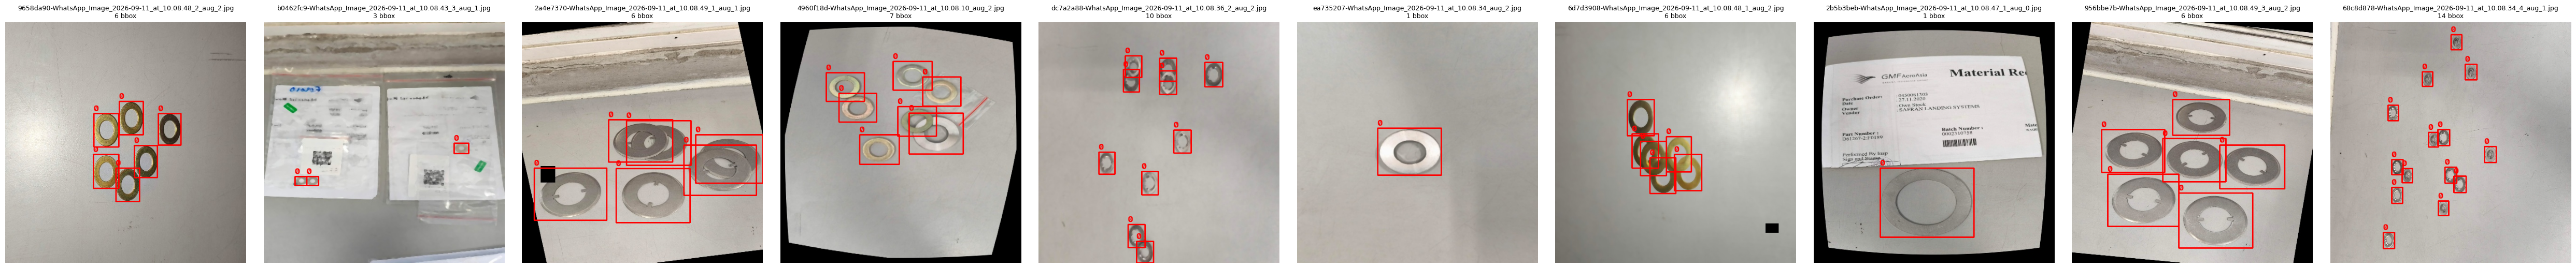


>>> Menampilkan sampel BERMASALAH saja (label kosong / bbox sangat kecil)


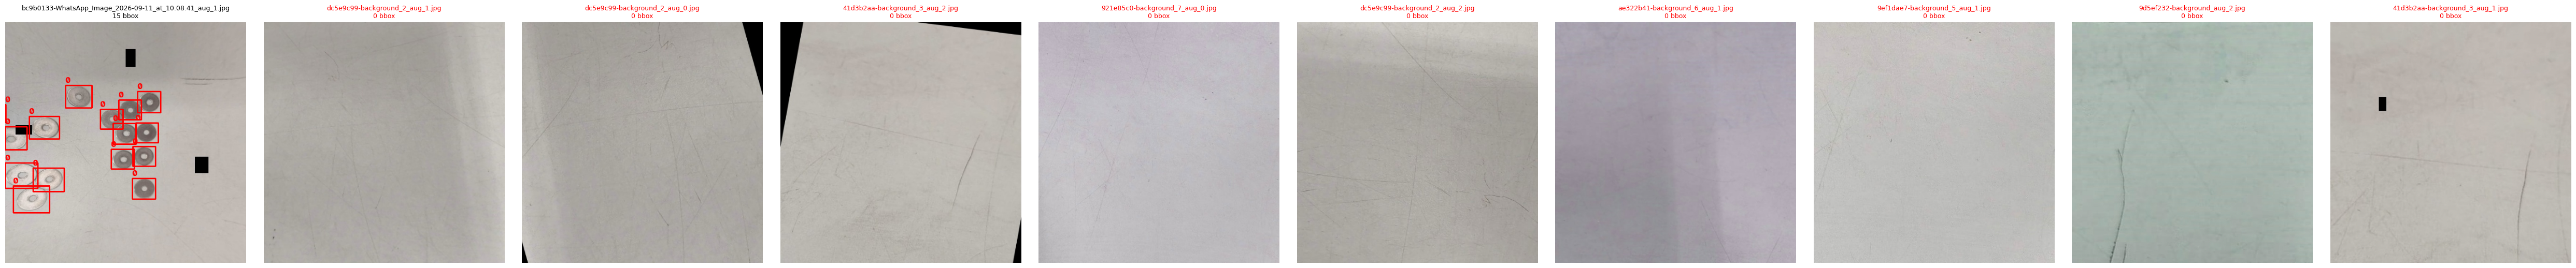

In [ ]:
"""
VERIFIKASI OUTPUT AUGMENTASI YANG SUDAH TERSIMPAN
====================================================
Skrip ini membaca LANGSUNG file .jpg + .txt yang sudah ada di folder
OUTPUT.

Fungsi utama:
1. scan_output_folder()   -> laporan cepat: berapa file label kosong,
                              berapa bbox super kecil (mencurigakan)
2. visualize_saved_samples() -> gambar bbox dari file .txt yang sudah
                                 tersimpan, di atas gambar .jpg yang sudah
                                 tersimpan juga (bukan hasil transform baru)
"""

import os
import cv2
import random
import matplotlib.pyplot as plt

OUTPUT_IMAGE_DIR = '/content/drive/MyDrive/Dataset Machine learning/augmented/images'
OUTPUT_LABEL_DIR = '/content/drive/MyDrive/Dataset Machine learning/augmented/labels'

MIN_REASONABLE_BOX_FRACTION = 0.01  # bbox lebih kecil dari 1% lebar/tinggi gambar dianggap mencurigakan


def read_yolo_labels(txt_path):
    bboxes, class_labels = [], []
    if not os.path.exists(txt_path):
        return bboxes, class_labels
    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(float(parts[0]))
                bbox = [float(x) for x in parts[1:]]
                bboxes.append(bbox)
                class_labels.append(cls_id)
    return bboxes, class_labels


def draw_yolo_bboxes(image, bboxes, class_labels, color=(255, 0, 0)):
    img = image.copy()
    h, w = img.shape[:2]
    for bbox, cls in zip(bboxes, class_labels):
        xc, yc, bw, bh = bbox
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, str(cls), (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img


# 1. SCAN SELURUH FOLDER OUTPUT -> LAPORAN RINGKAS
def scan_output_folder():
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')
    img_files = [f for f in os.listdir(OUTPUT_IMAGE_DIR) if f.lower().endswith(valid_ext)]

    empty_label_files = []      # gambar augmentasi TANPA bbox sama sekali
    missing_label_files = []    # gambar augmentasi yang file .txt-nya tidak ada
    tiny_bbox_entries = []      # bbox yang mencurigakan kecil
    ok_count = 0

    for img_name in img_files:
        base = os.path.splitext(img_name)[0]
        txt_path = os.path.join(OUTPUT_LABEL_DIR, f"{base}.txt")

        if not os.path.exists(txt_path):
            missing_label_files.append(img_name)
            continue

        bboxes, labels = read_yolo_labels(txt_path)
        if len(bboxes) == 0:
            empty_label_files.append(img_name)
            continue

        has_tiny = False
        for bbox in bboxes:
            _, _, bw, bh = bbox
            if bw < MIN_REASONABLE_BOX_FRACTION or bh < MIN_REASONABLE_BOX_FRACTION:
                tiny_bbox_entries.append((img_name, bbox))
                has_tiny = True

        if not has_tiny:
            ok_count += 1

    total = len(img_files)
    print("=" * 60)
    print(f"TOTAL FILE GAMBAR DI OUTPUT: {total}")
    print(f"  OK (bbox wajar)            : {ok_count}")
    print(f"  Label KOSONG (0 bbox)      : {len(empty_label_files)}")
    print(f"  Label file TIDAK ADA       : {len(missing_label_files)}")
    print(f"  Entri bbox SANGAT KECIL    : {len(tiny_bbox_entries)}")
    print("=" * 60)

    if empty_label_files:
        print(f"\nDaftar SELURUH file dengan label KOSONG (Total: {len(empty_label_files)}):")
        for f in empty_label_files:
            print(f"  - {f}")

    if missing_label_files:
        print(f"\nDaftar SELURUH file TANPA file label sama sekali (Total: {len(missing_label_files)}):")
        for f in missing_label_files:
            print(f"  - {f}")

    if tiny_bbox_entries:
        print(f"\nContoh bbox SANGAT KECIL, kemungkinan dibuang Roboflow saat import (max 10):")
        for f, bbox in tiny_bbox_entries[:10]:
            print(f"  - {f}: w={bbox[2]:.4f}, h={bbox[3]:.4f}")

    return {
        "total": total,
        "empty_label_files": empty_label_files,
        "missing_label_files": missing_label_files,
        "tiny_bbox_entries": tiny_bbox_entries,
    }


# 2. VISUALISASI SAMPEL YANG SUDAH TERSIMPAN
def visualize_saved_samples(n=6, only_problematic=False, scan_result=None):
    """
    only_problematic=True -> ambil sampel dari file yang label-nya kosong
                              atau bbox-nya sangat kecil (hasil scan_output_folder)
    only_problematic=False -> ambil sampel acak dari seluruh output
    """
    if only_problematic:
        if scan_result is None:
            scan_result = scan_output_folder()
        candidates = scan_result["empty_label_files"] + \
                     [f for f, _ in scan_result["tiny_bbox_entries"]]
        if not candidates:
            print("Tidak ada file bermasalah ditemukan.")
            return
        samples = random.sample(candidates, min(n, len(candidates)))
    else:
        valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')
        all_imgs = [f for f in os.listdir(OUTPUT_IMAGE_DIR) if f.lower().endswith(valid_ext)]
        samples = random.sample(all_imgs, min(n, len(all_imgs)))

    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for i, img_name in enumerate(samples):
        base = os.path.splitext(img_name)[0]
        img_path = os.path.join(OUTPUT_IMAGE_DIR, img_name)
        txt_path = os.path.join(OUTPUT_LABEL_DIR, f"{base}.txt")

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        bboxes, labels = read_yolo_labels(txt_path)

        vis = draw_yolo_bboxes(image, bboxes, labels, color=(255, 0, 0))
        axes[i].imshow(vis)
        title = f"{img_name}\n{len(bboxes)} bbox"
        axes[i].set_title(title, fontsize=9, color='red' if len(bboxes) == 0 else 'black')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 3. JALANKAN
if __name__ == "__main__":
    print(">>> Memindai seluruh folder output...")
    result = scan_output_folder()

    print("\n>>> Menampilkan sampel ACAK dari output (representatif keseluruhan)")
    visualize_saved_samples(n=10, only_problematic=False)

    print("\n>>> Menampilkan sampel BERMASALAH saja (label kosong / bbox sangat kecil)")
    visualize_saved_samples(n=10, only_problematic=True, scan_result=result)